In [ ]:
Import libraries.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from scipy.cluster.hierarchy import fcluster
from ISLP.cluster import compute_linkage

In [34]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples

In [3]:
np.random.seed(3)

## Data Preparation
Load the data.

In [4]:
parcels = pd.read_csv('seattle_parcels_with_tract.csv', low_memory = False)
parcels.head(5)

,Major,Minor,CurrentZoning,SqFtLot,NbrLivingUnits,ZipCode,Stories,BldgGrade,SqFtTotLiving,SqFtGarageAttached,Bedrooms,BathFullCount,YrBuilt,YrRenovated,Condition,ApprLandVal,ApprImpsVal,TaxableLandVal,TaxableImpsVal,GEOID
0,982870,2753,LR3 (M1),500,1.0,98122,3.0,8.0,1080.0,0.0,2.0,2.0,2021.0,0.0,3.0,340000.0,280000.0,340000.0,280000.0,53033007700
1,57900,1110,NR3,6322,1.0,98117,1.0,8.0,2320.0,230.0,3.0,1.0,1954.0,0.0,3.0,615000.0,390000.0,615000.0,390000.0,53033001600
2,287710,4110,NC2-55 (M),3960,1.0,98103,1.5,7.0,1780.0,0.0,4.0,1.0,1925.0,0.0,3.0,0.0,300.0,0.0,0.0,53033002900
3,287710,4110,NC2-55 (M),3960,1.0,98103,1.5,7.0,1780.0,0.0,4.0,1.0,1925.0,0.0,3.0,1279000.0,700.0,376000.0,128900.0,53033002900
4,390410,230,NR3,6750,1.0,98118,1.0,6.0,660.0,0.0,2.0,1.0,1918.0,0.0,3.0,308000.0,150000.0,308000.0,150000.0,53033011101


In [5]:
parcels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193074 entries, 0 to 193073
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Major               193074 non-null  int64  
 1   Minor               193074 non-null  int64  
 2   CurrentZoning       193074 non-null  object 
 3   SqFtLot             193074 non-null  int64  
 4   NbrLivingUnits      163499 non-null  float64
 5   ZipCode             147720 non-null  object 
 6   Stories             163499 non-null  float64
 7   BldgGrade           163499 non-null  float64
 8   SqFtTotLiving       163499 non-null  float64
 9   SqFtGarageAttached  163499 non-null  float64
 10  Bedrooms            163499 non-null  float64
 11  BathFullCount       163499 non-null  float64
 12  YrBuilt             163499 non-null  float64
 13  YrRenovated         163499 non-null  float64
 14  Condition           163499 non-null  float64
 15  ApprLandVal         189567 non-nul

In [6]:
acs = pd.read_csv('acs_tract_clean.csv')
acs.head(5)

,tractID,Median household income in the past 12 months (in 2024 inflation-adjusted dollars),Total:_x,Owner occupied,Renter occupied,Total:_y,White alone,Black or African American alone,American Indian and Alaska Native alone,Asian alone,...,pct_black,pct_asian,pct_amer_indian,pct_pacific_isl,pct_other_race,pct_two_plus_race,pct_renter_cost_burdened,pct_renter_severely_burdened,TRACTCE,GEOID
0,1.01,69577.0,1746,141,1605,3417,1693,652,0,422,...,0.190811,0.123500,0.000000,0.000000,0.038338,0.151888,0.443614,0.183178,101,53033000101
1,1.02,89840.0,2358,840,1518,4321,3121,362,0,431,...,0.083777,0.099745,0.000000,0.000000,0.052303,0.041888,0.563900,0.210804,102,53033000102
2,2.01,88833.0,2486,1269,1217,4953,2594,356,41,980,...,0.071876,0.197860,0.008278,0.000000,0.123360,0.074904,0.589154,0.171734,201,53033000201
3,2.02,138472.0,1549,1131,418,4404,2165,374,6,708,...,0.084923,0.160763,0.001362,0.000000,0.077203,0.184151,0.456938,0.358852,202,53033000202
4,3.00,135536.0,1201,865,336,2926,1797,179,11,612,...,0.061176,0.209159,0.003759,0.000342,0.007861,0.103554,0.324405,0.122024,300,53033000300


In [7]:
acs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 40 columns):
 #   Column                                                                              Non-Null Count  Dtype  
---  ------                                                                              --------------  -----  
 0   tractID                                                                             495 non-null    float64
 1   Median household income in the past 12 months (in 2024 inflation-adjusted dollars)  473 non-null    float64
 2   Total:_x                                                                            495 non-null    int64  
 3   Owner occupied                                                                      495 non-null    int64  
 4   Renter occupied                                                                     495 non-null    int64  
 5   Total:_y                                                                            495 non-null   

Join the data sets on GEOID.

In [8]:
df = pd.merge(parcels, acs, on = 'GEOID', how = 'left')
df.head(5)

,Major,Minor,CurrentZoning,SqFtLot,NbrLivingUnits,ZipCode,Stories,BldgGrade,SqFtTotLiving,SqFtGarageAttached,...,pct_white,pct_black,pct_asian,pct_amer_indian,pct_pacific_isl,pct_other_race,pct_two_plus_race,pct_renter_cost_burdened,pct_renter_severely_burdened,TRACTCE
0,982870,2753,LR3 (M1),500,1.0,98122,3.0,8.0,1080.0,0.0,...,0.692643,0.038529,0.084728,0.005404,0.00000,0.007497,0.171199,0.399381,0.113519,7700
1,57900,1110,NR3,6322,1.0,98117,1.0,8.0,2320.0,230.0,...,0.764634,0.007342,0.099735,0.000000,0.00000,0.018152,0.110137,0.239336,0.092417,1600
2,287710,4110,NC2-55 (M),3960,1.0,98103,1.5,7.0,1780.0,0.0,...,0.813563,0.019376,0.039397,0.000000,0.00000,0.001507,0.126157,0.434229,0.151344,2900
3,287710,4110,NC2-55 (M),3960,1.0,98103,1.5,7.0,1780.0,0.0,...,0.813563,0.019376,0.039397,0.000000,0.00000,0.001507,0.126157,0.434229,0.151344,2900
4,390410,230,NR3,6750,1.0,98118,1.0,6.0,660.0,0.0,...,0.394582,0.156657,0.203486,0.027299,0.00609,0.079378,0.132507,0.580030,0.259909,11101


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193074 entries, 0 to 193073
Data columns (total 59 columns):
 #   Column                                                                              Non-Null Count   Dtype  
---  ------                                                                              --------------   -----  
 0   Major                                                                               193074 non-null  int64  
 1   Minor                                                                               193074 non-null  int64  
 2   CurrentZoning                                                                       193074 non-null  object 
 3   SqFtLot                                                                             193074 non-null  int64  
 4   NbrLivingUnits                                                                      163499 non-null  float64
 5   ZipCode                                                                             14

Remove columns that identify the lot or are objects. 
Create a new dataframe to make it easier to later compare clusters to zip code and zoning.

In [10]:
df2 = df.drop(columns = ['Major', 'Minor', 'CurrentZoning', 'ZipCode', 'GEOID', 'tractID', 'TRACTCE'])
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193074 entries, 0 to 193073
Data columns (total 52 columns):
 #   Column                                                                              Non-Null Count   Dtype  
---  ------                                                                              --------------   -----  
 0   SqFtLot                                                                             193074 non-null  int64  
 1   NbrLivingUnits                                                                      163499 non-null  float64
 2   Stories                                                                             163499 non-null  float64
 3   BldgGrade                                                                           163499 non-null  float64
 4   SqFtTotLiving                                                                       163499 non-null  float64
 5   SqFtGarageAttached                                                                  16

Drop rows with NaN for AgglomerativeClustering. 
If this seems to be biasing data, can impute instead.

In [11]:
df_dropNaN = df2.dropna()

Scale the data.

In [12]:
scaler = StandardScaler(with_std=True,
                        with_mean=True)
df_scaled = scaler.fit_transform(df_dropNaN)

## Modeling

### Hierarchical Clustering

Sample the data to allow hierarchical clustering to work. 
Use df so can compare zip code, etc, to clusters. 

In [16]:
# Drop NaN before sample
df_hc_drop = df.dropna()

In [17]:
df_sample = df_hc_drop.sample(500, random_state = 3)

In [19]:
# Drop columns don't want involved in cluster.
df_hc = df_sample.drop(columns = ['Major', 'Minor', 'CurrentZoning', 'ZipCode', 'GEOID', 'tractID', 'TRACTCE'])

In [22]:
df_hc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 64970 to 183344
Data columns (total 52 columns):
 #   Column                                                                              Non-Null Count  Dtype  
---  ------                                                                              --------------  -----  
 0   SqFtLot                                                                             500 non-null    int64  
 1   NbrLivingUnits                                                                      500 non-null    float64
 2   Stories                                                                             500 non-null    float64
 3   BldgGrade                                                                           500 non-null    float64
 4   SqFtTotLiving                                                                       500 non-null    float64
 5   SqFtGarageAttached                                                                  500 non-null 

In [20]:
# Scale the sample data
df_hc_scaled = scaler.fit_transform(df_hc)

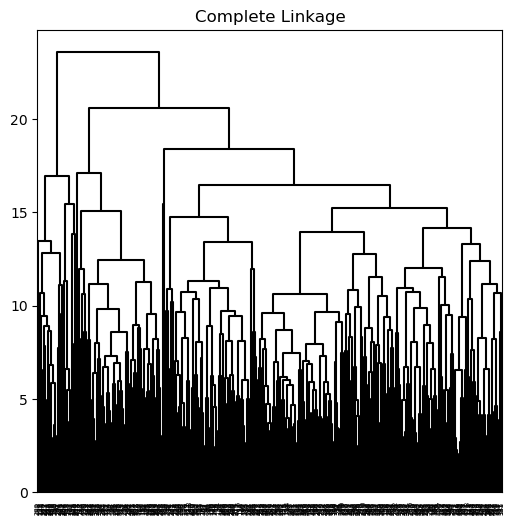

In [23]:
HClust = AgglomerativeClustering

cargs = {'color_threshold': -np.inf,
         'above_threshold_color': 'black'}

# COMPLETE
hc_comp = HClust(distance_threshold=0, n_clusters=None, linkage='complete')
hc_comp.fit(df_hc_scaled)
linkage_comp = compute_linkage(hc_comp)

plt.figure(figsize=(6,6))
dendrogram(linkage_comp, **cargs)
plt.title("Complete Linkage")
plt.show()

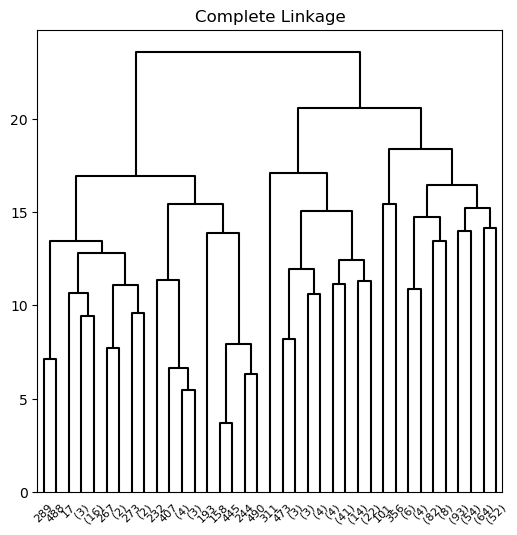

In [25]:
# Only show top levels of dendogram
plt.figure(figsize=(6,6))
dendrogram(linkage_comp, truncate_mode='level', p=5, **cargs)
plt.title("Complete Linkage")
plt.show()

In [27]:
hc = AgglomerativeClustering(n_clusters=5, linkage='complete')
clusters = hc.fit_predict(df_hc_scaled)

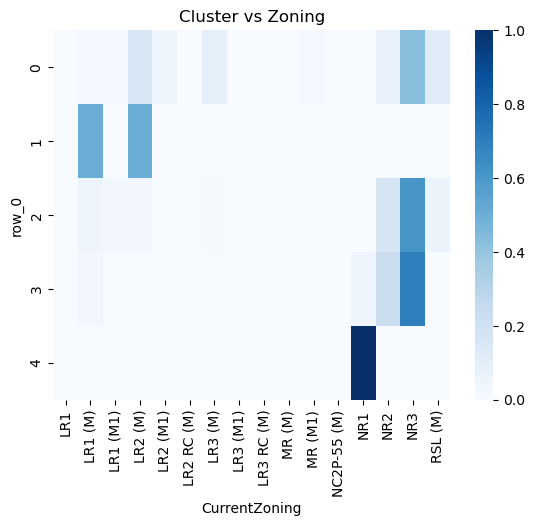

In [29]:
ct = pd.crosstab(clusters, df_sample['CurrentZoning'], normalize='index')

sns.heatmap(ct, cmap='Blues')
plt.title('Cluster vs Zoning')
plt.show()

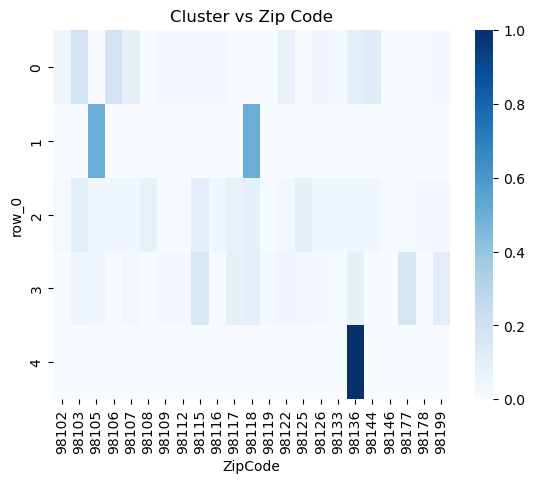

In [31]:
ctz = pd.crosstab(clusters, df_sample['ZipCode'], normalize='index')

sns.heatmap(ctz, cmap='Blues')
plt.title('Cluster vs Zip Code')
plt.show()

### K-Means Clustering

Redo dropping NaN, dropping the columns, and scaling, in this order, so we can compare clusters to zoning and zip code.

In [43]:
# First drop NaN
df_with_labels = df.dropna()

In [44]:
# Second drop columns not needed in clustering
df_model = df_with_labels.drop(columns = ['Major', 'Minor', 'CurrentZoning', 'ZipCode', 'GEOID', 'tractID', 'TRACTCE'])

In [45]:
# Third scale the data for modeling
scaler = StandardScaler(with_std=True,
                        with_mean=True)
df_scaled = scaler.fit_transform(df_model)

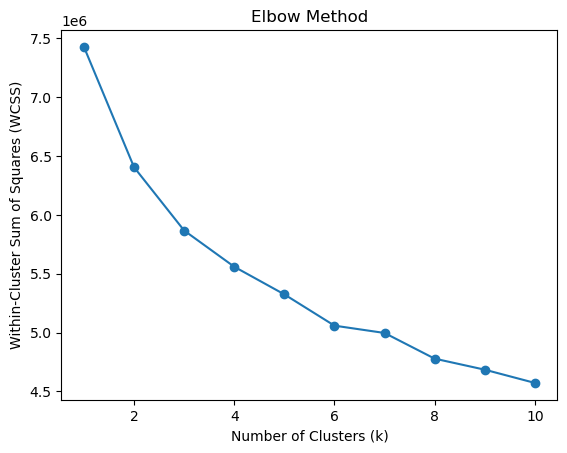

In [46]:
# Examine k-means vs within-cluster sum of squares

inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)  
    inertia.append(kmeans.inertia_)

# Plot
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method')
plt.show()

Determine silhouette scores for different k values. 
Use sample of data set because silhouette scores are computationally expensive and data set is large.

In [47]:
for k in [3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=3)
    labels = kmeans.fit_predict(df_scaled)

    # sample for silhouette
    idx = np.random.choice(df_scaled.shape[0], 5000, replace=False)
    
    score = silhouette_score(df_scaled[idx], labels[idx])
    
    print(f"k={k}, silhouette={score}")

k=3, silhouette=0.1557125738414128
k=4, silhouette=0.14224732367781695
k=5, silhouette=0.11117592358167674


Chose k = 3 because it looks good using the elbow method and it had the strongest silhouette score.

In [50]:
kmeans = KMeans(n_clusters=3,
                random_state=3,
                n_init=20).fit(df_scaled)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters = kmeans.fit_predict(df_scaled)

In [51]:
# Create a k-means copy of the data with labels to attach the clusters to
df_kmeans = df_with_labels.copy()

In [52]:
# Attach the labels to the dataframe
df_kmeans['cluster'] = clusters

Compare the clusters to the zoning.

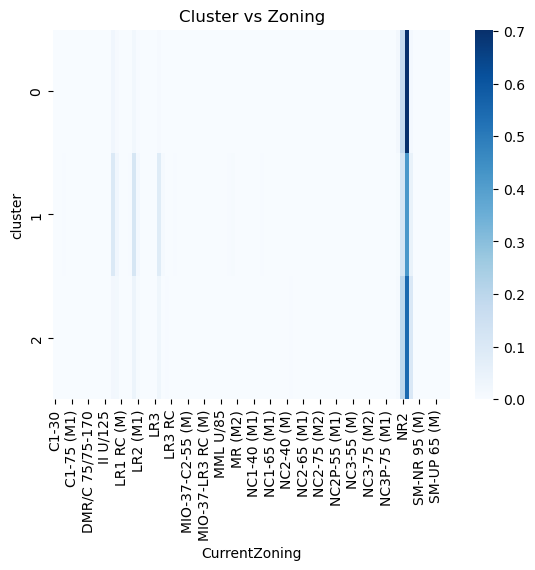

In [53]:
ct3_zone = pd.crosstab(df_kmeans['cluster'], df_kmeans['CurrentZoning'], normalize='index')

sns.heatmap(ct3_zone, cmap='Blues')
plt.title('Cluster vs Zoning')
plt.show()

Cluster 0 is dominated by NR2 zoning. The other clusters also show a lot of NR2 zoning. It is a factor in all the clusters, but it doesn't uniquely define one cluster since it is present in all of them.

Compare the clusters to the zip code.

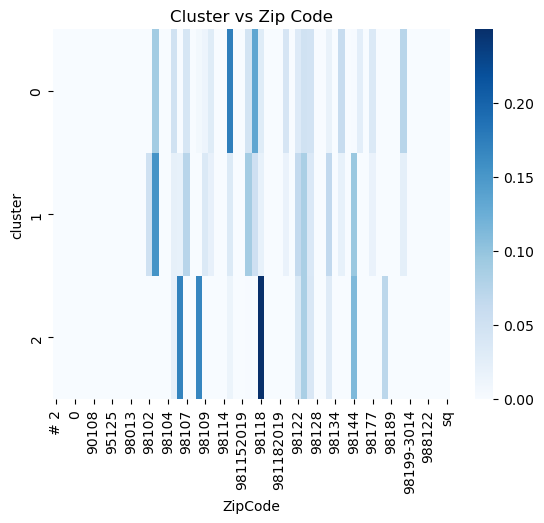

In [54]:
ct3_zip = pd.crosstab(df_kmeans['cluster'], df_kmeans['ZipCode'], normalize='index')

sns.heatmap(ct3_zip, cmap='Blues')
plt.title('Cluster vs Zip Code')
plt.show()

The clusters align more closely with zoning than with zip codes. This suggests that the variables we are using as predictors are more closely related to land use regulation than geographic boundaries. Some clusters show concentration in some zip codes. The clustering is not primarily driven by geographic location.

In [55]:
df_kmeans['CurrentZoning'].value_counts()

CurrentZoning
NR3                  85116
NR2                  23661
LR2 (M)               7210
RSL (M)               6335
LR1 (M)               6332
                     ...  
NC2-75 (M2)              1
MIO-65-NC2-55 (M)        1
MIO-240-MR (M)           1
NC3P-65 (M1)             1
MR                       1
Name: count, Length: 96, dtype: int64